# Regression
1. search for dataset for regression model
2. check the data and explore to deffine the suitable model
3. visualization using seaborn (heatmap)
4. decide whcih model you will use
5. prepare the data for modelling
6. train the model
7. evaluate the trained model
8. try another model and impurt it again in production using gradio

In [2]:
import pandas as pd

df= pd.read_csv("./saudi_aramco_data.csv")
df = df.iloc[:,1:] # remove date

X = df.iloc[:,:-2]
y = df.iloc[:,-2]
X.head()

,Open,High,Low,Close
0,29.090908,29.090908,29.090908,29.090908
1,31.983471,31.983471,29.752066,30.413223
2,30.661158,30.991735,30.413223,30.909090
3,30.991735,31.487602,30.991735,31.404959
4,31.446280,31.528925,30.991735,31.198347


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split

XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.3)

# scaler = StandardScaler()
# scaler.fit(XTrain, yTest)

# xTrain2 = scaler.transform(XTrain)
# display(xTrain2)

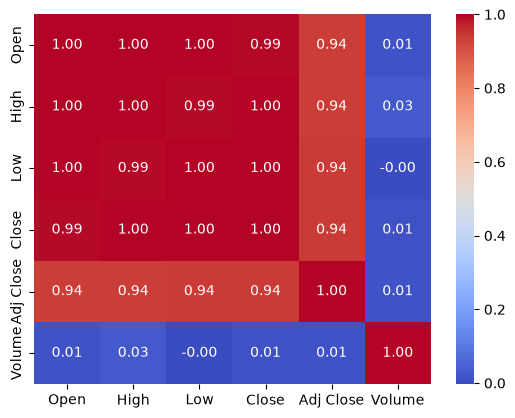

In [5]:

# dfX = pd.DataFrame(df).corr()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# I will use Ridge Regression

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def print_metric(yPred, yTest, name):
    print(name)
    print("mean_absolute_error:", round(mean_absolute_error(yPred, yTest), 4))
    print("mean_squared_error:", round(mean_squared_error(yPred, yTest), 4))
    print("r2_score:", round(r2_score(yPred, yTest), 4))

ridgeModel
mean_absolute_error: 0.9888
mean_squared_error: 1.3783
r2_score: 0.8669


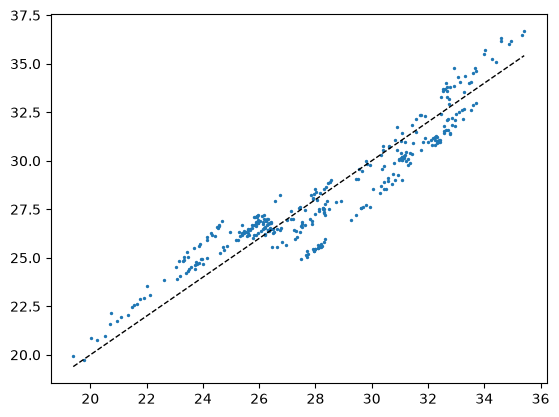

--------------------------------------------------
ridgeModel2
mean_absolute_error: 0.8076
mean_squared_error: 1.1252
r2_score: 0.8989


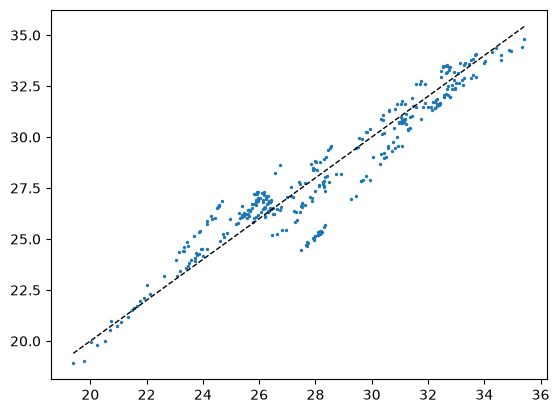

--------------------------------------------------
lassoModel
mean_absolute_error: 1.3905
mean_squared_error: 2.4387
r2_score: 0.518


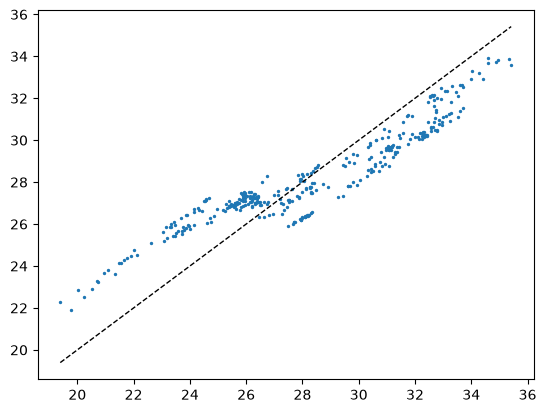

--------------------------------------------------
elasticNetModel
mean_absolute_error: 1.2382
mean_squared_error: 2.0363
r2_score: 0.6666


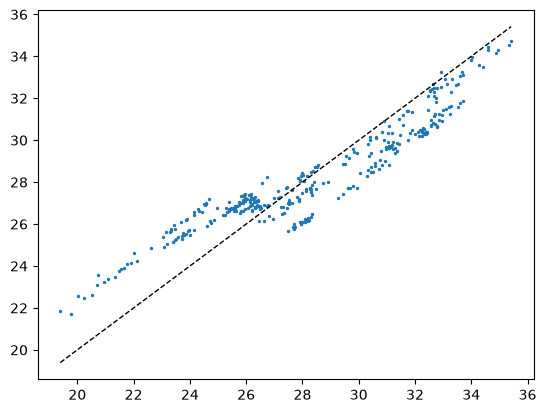

--------------------------------------------------


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, LinearRegression, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import PredictionErrorDisplay

ridgeModel = make_pipeline(
    StandardScaler(),
    Ridge(alpha=100)
)
ridgeModel2 = make_pipeline(
    PolynomialFeatures(degree=10),
    StandardScaler(),
    Ridge()
)
lassoModel = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1)
)
elasticNetModel = make_pipeline(
    StandardScaler(),
    ElasticNet()
)


all_models = {
    "ridgeModel": ridgeModel,
    "ridgeModel2": ridgeModel2,
    "lassoModel": lassoModel,
    "elasticNetModel": elasticNetModel,

}

for name, model in all_models.items():
    model.fit(XTrain, yTrain)
    yPred = model.predict(XTest)
    print_metric(yPred, yTest, name)

    plt.scatter(yTest, yPred, s=2)
    plt.plot([yTest.min(), yTest.max()],[yTest.min(), yTest.max()], 'k--', lw=1 )
    # PredictionErrorDisplay.from_estimator(model, XTest, yTest, kind="actual_vs_predicted")
    plt.show()
    print("-"*50)

    



ridgeModel
ridgeModel2
lassoModel
elasticNetModel


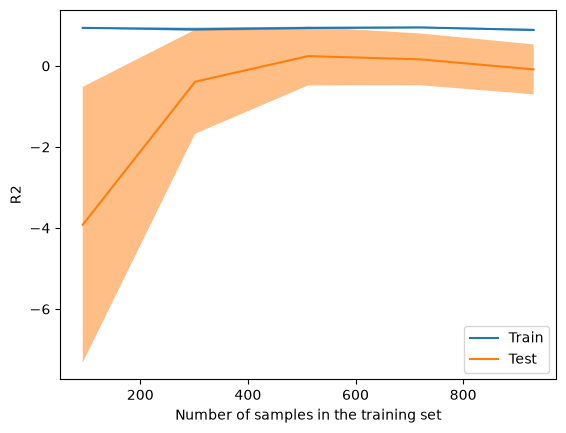

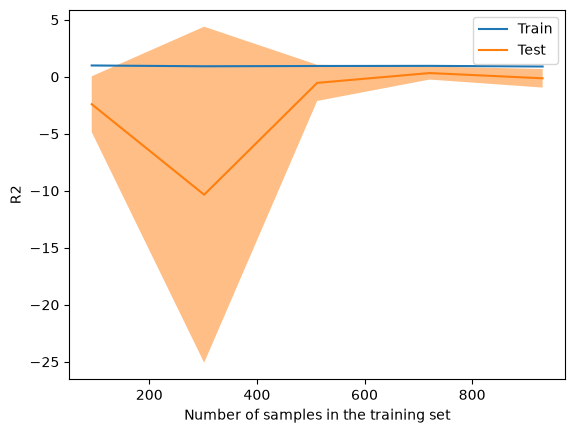

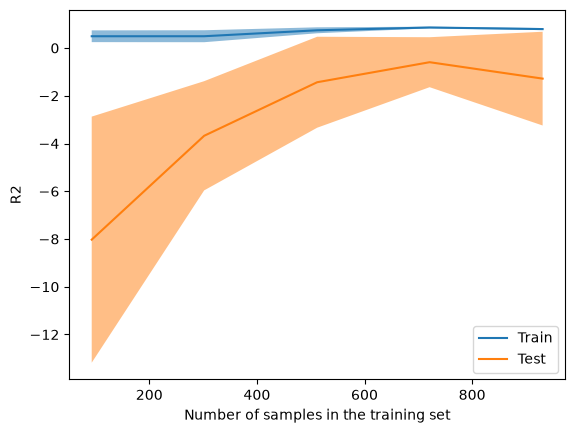

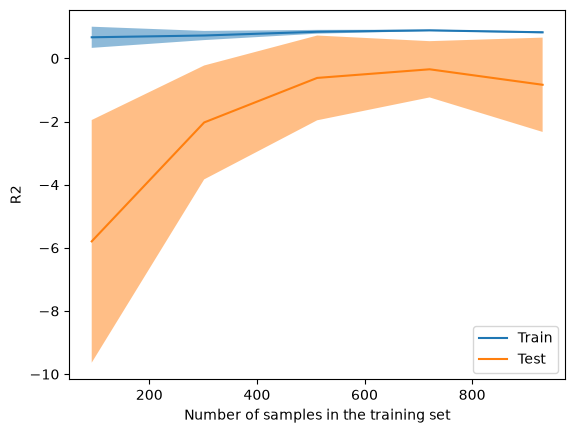

In [8]:
from sklearn.model_selection import LearningCurveDisplay
# import numpy as np

for name, model in all_models.items():
    print(name)
    LearningCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        scoring="r2",
    )

In [9]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(ridgeModel2, file)


In [10]:
with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# print(loaded_model)
yPred = loaded_model.predict(XTest)
print_metric(yTest, yPred, "loaded model")

loaded model
mean_absolute_error: 0.8076
mean_squared_error: 1.1252
r2_score: 0.9074


In [11]:
XTrain.columns

Index(['Open', 'High', 'Low', 'Close'], dtype='str')

In [19]:
f = [29.09090805053711,29.363636016845703,29.0,29.27272605895996]

In [20]:
f

[29.09090805053711, 29.363636016845703, 29.0, 29.27272605895996]

/Users/rashed/Documents/GitHub/aramco_stock_AvgClose/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([26.74771063])

In [ ]:
import gradio as gr

def predict(open_at, high, low, close):
    params = [open_at, high, low, close]
    adjClose_prediction = loaded_model.predict([params])[0]

    if adjClose_prediction is None:
        return "Cannot Predict, because something is wrong"
    
    return f"adj Close is on: {adjClose_prediction}"

inputs = [
    gr.Number(label="Open At:", precision=4, value=30),
    gr.Number(label="High:", precision=4, value=30),
    gr.Number(label="Low: ", precision=4, value=30),
    gr.Number(label="Close: ", precision=4, value=30),
]

demo = gr.Interface(fn=predict, title="Aramco Stock Predictor", inputs=inputs, outputs="text")

demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
